# Explore the DES Y3 × Planck PR4 shear predictions

This notebook calls the compiled CosmoLike library of the `desy1xplanck` project directly from Python, without Cobaya, to inspect the predictions behind its likelihood. The data combine DES Year 3 galaxy shapes and magnitude-limited (MagLim) lens galaxies with the Planck PR4 map of CMB lensing. The cells cover

- the cosmic-shear angular power spectra $C_\ell^{EE}$ and correlation functions $\xi_\pm(\theta)$, and their response to cosmological, intrinsic-alignment and baryonic-feedback parameters;
- the numerical changes produced by the accuracy settings of CAMB and CosmoLike;
- the cosmic-shear $\chi^2$ against the measured data vector, as in [EXAMPLE_EVALUATE1.yaml](EXAMPLE_EVALUATE1.yaml), with two models of the nonlinear matter power spectrum (Halofit and EuclidEmulator2);
- response functions: the wavenumbers $k$ of the matter power spectrum on which each measurement depends;
- the cross-correlation of CMB lensing and cosmic shear, $C_\ell^{\kappa s}$ and $w_{\kappa s}(\theta)$.

The likelihood's data vector, the ordered list of measured values, has 1,809 entries. The 1,500 galaxy/shear entries are $\xi_+$ and $\xi_-$ (300 each: 10 source-bin pairs × 30 angular bins), galaxy–galaxy lensing $\gamma_t$ (720: 24 lens–source pairs × 30) and galaxy clustering $w$ (180: 6 lens bins × 30). The 309 CMB-lensing entries are CMB lensing × galaxies (180), CMB lensing × shear (120) and nine bandpowers of the CMB-lensing auto-spectrum. These observables need their own model ingredients: a single source plane at last scattering, the filtering of the lensing map and the bandpower binning. The covariance generated by [EXAMPLE_EVALUATE_COVARIANCE.ipynb](EXAMPLE_EVALUATE_COVARIANCE.ipynb) covers the galaxy/shear entries only; the likelihood uses the supplied 1,809-entry matrix.

Compile the project and start Jupyter from an activated Cocoa environment, as the [project README](README.md#notebooks) describes. Every prediction runs CAMB once, so a sweep over 10–40 parameter values takes minutes.

| Convention | In this notebook |
| --- | --- |
| Source bins | 4 tomographic (redshift) bins; cosmic shear has 10 pairs $(i,j)$ with $i\le j$ |
| Lens bins | 6 MagLim bins; they enter the $\chi^2$ machinery, not the figures |
| Angle $\theta$ | arcminutes; 30 logarithmic bins from 0.25′ to 250′, each represented by its area-weighted center |
| Multipole $\ell$ | spectra are evaluated at the multipoles in `ell`, in the Limber approximation: multipole $\ell$ at comoving distance $\chi$ probes $k=(\ell+1/2)/\chi$ |
| Wavenumber $k$ | $h\,\mathrm{Mpc}^{-1}$ |
| Array axes | `C_ss` (EE and BB): `[ell, i, j]`; `xi_plus`, `xi_minus`: `[theta, i, j]`; `C_ks`, `w_ks`: `[ell or theta, i]` |
| Bin numbers | arrays count bins from 0 and panel labels from 1: panel (1,2) draws `[:, 0, 1]` |

## Set up the Python session

The first two cells prepare the *kernel*, the Python process that runs the cells of this notebook.

- `OMP_NUM_THREADS` sets how many OpenMP threads (parallel workers inside the compiled C code) CosmoLike uses. The cell assigns it before the compiled library is imported, replacing the value exported in the shell.
- `cosmolike_desy1xplanck_interface`, imported as `ci`, is this project's compiled CosmoLike library, exposed to Python with pybind11.
- The `rcParams` lines set matplotlib's figure style for the whole session. `text.usetex = True` typesets every label with LaTeX and needs the LaTeX packages listed in the cell.
- The second cell imports CAMB, the shared package `cosmolike_notebook_utils` (as `cnu`: the CAMB helper and the plotting functions every Cocoa project uses) and this project's notebook wrappers (as `nw`, defined in [interface/cosmolike_desy1xplanck_notebook_wrappers.py](interface/cosmolike_desy1xplanck_notebook_wrappers.py)).

The printed working directory must be this project's folder, because the wrappers find the dataset through a path relative to it. The other printed paths show which installations were loaded.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
# OpenMP threads of the compiled CosmoLike loops: assigned before the
# interface import below, replacing the shell's OMP_NUM_THREADS. Keep it
# at or below the number of physical cores.
os.environ['OMP_NUM_THREADS'] = '10'
import matplotlib
import math
import warnings
from matplotlib import pyplot as plt
import numpy as np
import euclidemu2
import scipy
import cosmolike_desy1xplanck_interface as ci
from getdist import IniFile
import itertools
import iminuit
import functools
from scipy.interpolate import interp1d
print(sys.version)
print(os.getcwd())

# Figure style for the whole session (matplotlib's global rcParams); the
# shared plotting functions never change these settings.
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'

# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# usetex typesets every label with LaTeX. It needs texlive-latex-base,
# texlive-latex-extra, texlive-fonts-recommended, dvipng, ghostscript and
# cm-super; set it to False when they are not installed.
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Display only: a wider notebook page and a taller output scroll area.
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.


3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/desy1xplanck


In [2]:
# CAMB. Python skips the build folder named below when it does not exist (other
# platforms and build tools name it differently) and then imports the CAMB
# already on its search path; the print shows which installation was loaded.
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# The notebook package shared by every Cocoa project (CAMB helper, plots).
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))


# This project's notebook wrappers (interface/, on the PYTHONPATH that
# start_cocoa.sh extends): the probe, chi2 and response functions shared
# by every notebook of this project.
import cosmolike_desy1xplanck_notebook_wrappers as nw
print('Using notebook wrappers installed at %s'%(nw.__file__))

Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb
Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils
Using notebook wrappers installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/desy1xplanck/interface/cosmolike_desy1xplanck_notebook_wrappers.py


## Mirror the YAML settings

The next cell repeats choices of [EXAMPLE_EVALUATE1.yaml](EXAMPLE_EVALUATE1.yaml). `nw.configure` hands five of them to the wrappers:

- `ntheta`, `theta_min_arcmin` and `theta_max_arcmin`, the angular binning of $\xi_\pm(\theta)$;
- `non_linear_emul`, the nonlinear matter power spectrum: 1 for EuclidEmulator2, 2 for Halofit;
- `lmax`, the highest multipole of the internal $C_\ell$ table that is summed into $\xi_\pm(\theta)$. The smallest angle, 0.25′, needs multipoles of several times $10^4$, far above the range plotted below.

The remaining names only document the YAML; no later cell reads them. The wrappers already hold the same intrinsic-alignment model, NLA with a power-law redshift dependence.

The cell after it imports the fiducial point, the reference parameter values stored in the wrappers module. Each sweep below varies one of them and keeps the others; any wrapper call can also override a value, e.g. `nw.get_chi2(omegam=0.31)`.

In [3]:
# Values copied from EXAMPLE_EVALUATE1.yaml. Only the five handed to
# nw.configure below reach the wrappers; CAMBAccuracyBoost, CLprobe, path,
# data_file and the IA_* names are not read by later cells. The wrappers
# keep the same IA choices; nw.configure(IA_model=...) before
# nw.init_cosmolike changes them.
CAMBAccuracyBoost = 1.0
non_linear_emul = 2
CLprobe="xi"

path= "../../external_modules/data/desy1xplanck"
data_file="Y3xPlanckPR4.dataset"

IA_model = 0
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)

ntheta = 30
theta_min_arcmin = 0.25
theta_max_arcmin = 250
lmax = 75000

# hand this notebook's yaml-mirroring values to the shared wrappers
nw.configure(lmax=lmax,
             ntheta=ntheta,
             theta_min_arcmin=theta_min_arcmin,
             theta_max_arcmin=theta_max_arcmin,
             non_linear_emul=non_linear_emul)

In [4]:
# The project fiducial point lives in the wrappers module
# (interface/cosmolike_desy1xplanck_notebook_wrappers.py), shared by
# every notebook. The names are imported so the sweep cells below can
# build shifted vectors from them; override any value per call
# instead, e.g. nw.get_chi2(omegam=0.31).
from cosmolike_desy1xplanck_notebook_wrappers import (
    As_1e9, ns, H0, omegab, omegam, mnu, w, w0pwa,
    DES_A1_1, DES_A1_2,
    DES_DZ_S1, DES_DZ_S2, DES_DZ_S3, DES_DZ_S4,
    DES_M1, DES_M2, DES_M3, DES_M4,
    DES_DZ_L1, DES_DZ_L2, DES_DZ_L3, DES_DZ_L4, DES_DZ_L5, DES_DZ_L6,
    DES_DZ2_L1, DES_DZ2_L2, DES_DZ2_L3, DES_DZ2_L4, DES_DZ2_L5, DES_DZ2_L6,
    DES_B1_1, DES_B1_2, DES_B1_3, DES_B1_4, DES_B1_5, DES_B1_6,
    DES_BMAG_1, DES_BMAG_2, DES_BMAG_3, DES_BMAG_4, DES_BMAG_5, DES_BMAG_6,
    DES_PM1, DES_PM2, DES_PM3, DES_PM4, DES_PM5, DES_PM6)

## What one wrapper call does

The compiled library keeps *global state*: it stores the cosmology tables, nuisance parameters and binning between calls, and every compute function reads the values set last. So that no call depends on the one before it, each wrapper (`nw.C_ss_tomo_limber`, `nw.xi`, `nw.get_chi2`, ...) rebuilds the complete state in four stages.

1. **CAMB.** `cnu.get_camb_cosmology` runs CAMB once. It returns the linear and nonlinear matter power spectra as $\ln P$, with $P$ in $(\mathrm{Mpc}/h)^3$, on a grid of $\log_{10}k$ with $k$ in $h\,\mathrm{Mpc}^{-1}$, together with the growth factor and the comoving distance $\chi(z)$ in $\mathrm{Mpc}/h$, on redshift and wavenumber grids that follow the likelihood's.
2. **`ci.set_cosmology`.** The tables enter the C library, which interpolates them in every later integral. New tables also invalidate CosmoLike's caches: stored intermediate results, such as $C_\ell$ tables, that are reused until an input changes.
3. **Nuisance setters.** `ci.set_nuisance_shear_calib` sets the multiplicative shear biases $m_i$ (the measured shear is $1+m_i$ times the true one), `ci.set_nuisance_shear_photoz` shifts each source redshift distribution by $\Delta z_i$, and `ci.set_nuisance_ia` sets the intrinsic-alignment parameters. `nw.get_chi2` also sets the lens redshift shifts and stretches, the galaxy and magnification biases and the point-mass terms; probes that are not selected ignore them.
4. **Prediction.** `ci.C_ss_tomo_limber`, `ci.xi_pm_tomo`, `ci.w_ks_tomo` or `ci.compute_data_vector_masked` evaluates the requested quantity from that state.

The wrappers also translate the accuracy arguments described before the accuracy figures. The three comment cells below say where each function lives; `help(nw.xi)` prints the arguments of a wrapper.

In [5]:
# get_camb_cosmology lives in cosmolike_core, shared by every project's
# notebooks; call it as cnu.get_camb_cosmology (imported above):
# external_modules/code/cosmolike_core/cosmolike_notebook_utils


In [6]:
# C_ss_tomo_limber lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.C_ss_tomo_limber.

In [7]:
# xi lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.xi.

## Initialize the interface

`nw.init_cosmolike()` performs the setup that the likelihood runs when it starts. It reads [the dataset file](data/Y3xPlanckPR4.dataset), a small text file naming the redshift distributions, data vector, covariance, mask and CMB-lensing inputs. It then sets the angular binning, the redshift-distribution conventions, the CMB-lensing filters, the intrinsic-alignment model and the 6 lens and 4 source redshift distributions. Called without arguments, it skips the probe selection and the data files, which only the $\chi^2$ cells need. `nw.allsims` names the HDF5 file of hydrodynamical-simulation power-spectrum ratios used by the baryonic-feedback cells.

In [8]:
# Init Cosmolike (the full sequence lives in nw.init_cosmolike)
ini = nw.init_cosmolike()
# The HDF5 file of hydrodynamical-simulation power-spectrum ratios named
# in the dataset; the baryonic-feedback cells pass it back to the wrappers.
allsims = nw.allsims

## The shared plotting functions

The figures use plotting functions of `cosmolike_notebook_utils` (`cnu`), which the two comment cells below name. They receive numpy arrays only and never call CAMB or the compiled library.

- `cnu.plot_C_ss_tomo_limber` and `cnu.plot_xi` draw one panel per source-bin pair $(i,j)$, arranged as a lower triangle.
- Without a reference, a $C_\ell$ panel shows $\ell(\ell+1)C_\ell^{EE}/2\pi$ on a logarithmic axis, and a $\xi$ panel shows $\theta\,\xi_\pm\times10^4$ with $\theta$ in arcminutes. With `rescale=1`, each panel is multiplied by its own power of ten, printed inside it as $\alpha$, so that all panels share one y range.
- With a reference (`C_ss_ref`, `xi_ref`), each panel shows the fractional difference value/reference − 1, and `ylim` is given as multipliers around 1: `ylim=(0.98, 1.02)` draws a ±2% band.
- `param` and `colorbarlabel` color a parameter sweep: each curve takes the color that the colorbar shows at its value. `plot_xi(pm=1, ...)` draws $\xi_+$; a `pm` of zero or less draws $\xi_-$.

`help(cnu.plot_xi)` lists every option.

In [9]:
# plot_C_ss_tomo_limber lives in cosmolike_core (shared); call it as
# cnu.plot_C_ss_tomo_limber (imported above)


In [10]:
# plot_xi lives in cosmolike_core (shared); call it as cnu.plot_xi
# (imported above)

## How cosmological and intrinsic-alignment parameters change $C_\ell^{EE}$

$C_\ell^{EE,ij}$ is the angular power spectrum of the E-mode (curl-free) part of the cosmic shear between source bins $i$ and $j$. Each sweep calls the wrapper once per value and keeps every other parameter at the fiducial point:

- $\Omega_m$ from 0.20 to 0.38, drawn as absolute spectra with `rescale=1`;
- the spectral index $n_s$ from 0.85 to 1.09, as fractional differences from the fiducial spectrum `ref`;
- the intrinsic-alignment amplitude $A_{\rm IA}$ from 0 to 2.9 and its redshift exponent $\eta_{\rm IA}$ from −2 to 1.9, also relative to `ref`.

Intrinsic alignment is the correlated orientation of galaxy shapes caused by the tidal field around them; it adds to the lensing signal. In the NLA (nonlinear alignment) model used here, the amplitude at redshift $z$ is $A_{\rm IA}\,[(1+z)/1.62]^{\eta_{\rm IA}}$, with fiducial values $A_{\rm IA}=-0.7$ and $\eta_{\rm IA}=-1.7$. The wrappers receive both as `A1 = [A_IA, eta_IA, 0, 0]`. In each sweep, `tmp` receives the B-mode spectrum $C_\ell^{BB}$, which these figures do not use.

In [11]:
# lmin and lmax set the plotted multipole range only; the C_ell table
# cutoff lmax = 75000 was handed to nw.configure above.
lmin = 100.
lmax = 4500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.2, 0.4, 0.02)     
C_ss = []
for x in param:
    # The wrapper returns (EE, BB); tmp receives the B-mode spectrum.
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, omegam=x)
    C_ss.append(Cl)

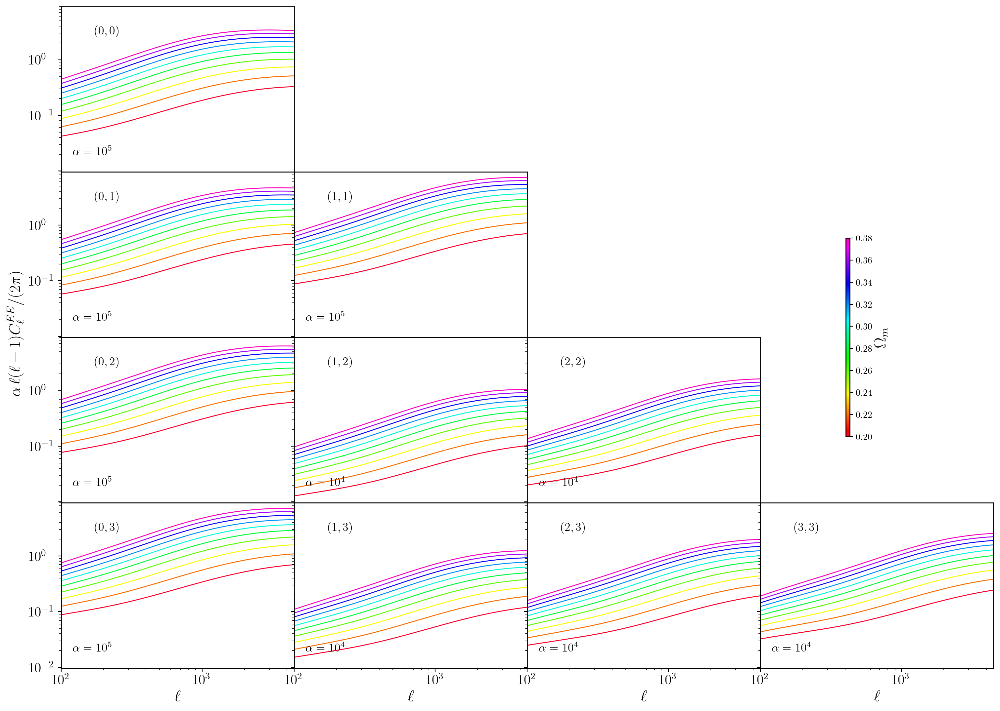

In [12]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          param=param,
                          colorbarlabel="$\Omega_m$",
                          yaxislabelsize = 17,
                          xaxislabelsize = 17,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          figsize = (18, 13),
                          lmin = lmin,
                          lmax = lmax,
                          wspace=0.4,
                          rescale=1,
                          ydecades=4)

In [13]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin,lmax, 20.) # Make sure arange are with float numbers (otherwise there are aliasing problems)
param = np.arange(0.85, 1.1, 0.02)
C_ss = []
for x in param:
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, ns=x)
    C_ss.append(Cl)
# Fiducial spectrum: the reference of this figure and of the two
# intrinsic-alignment sweeps below.
(ref, tmp) = nw.C_ss_tomo_limber(ell=ell)

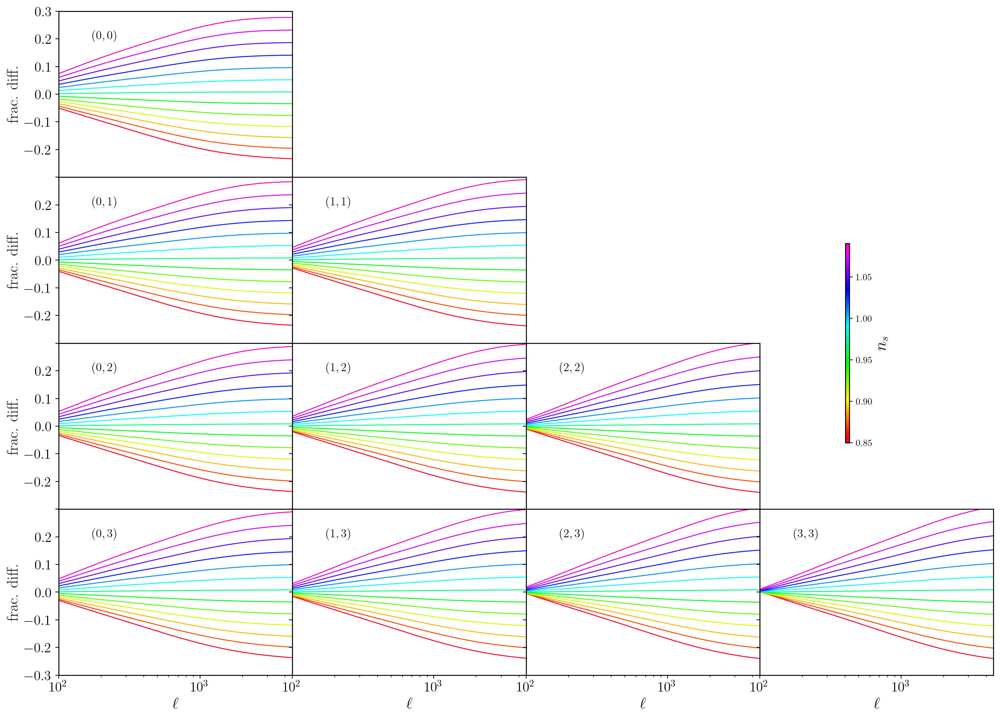

In [14]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=ref,
                          param=param,
                          colorbarlabel="$n_s$",
                          figsize = (18, 13),
                          yaxislabelsize = 17,
                          xaxislabelsize = 17,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          lmin = lmin,
                          lmax = lmax,
                          ylim = [0.7,1.3],
                          wspace=0.4)

In [15]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.0, 3, 0.1)     
C_ss = []
for x in param:
    # A1 = [A_IA, eta_IA, 0, 0]: the NLA amplitude at redshift z is
    # A_IA ((1 + z)/1.62)^eta_IA. This sweep varies A_IA.
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, A1 = [x, DES_A1_2, 0, 0])
    C_ss.append(Cl)

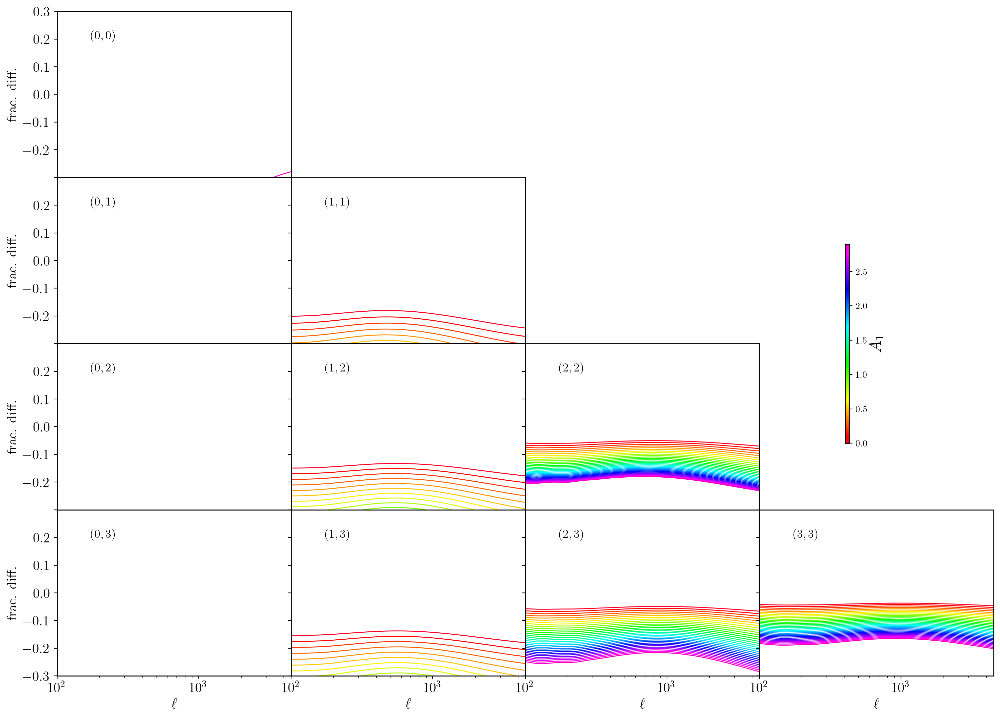

In [16]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=ref,
                          param=param,
                          colorbarlabel="$A_1$",
                          figsize = (18, 13),
                          yaxislabelsize = 15,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          lmin = lmin,
                          lmax = lmax,
                          ylim = [0.7,1.3],
                          wspace=0.4)

In [17]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(-2, 2, 0.1)     
C_ss = []
for x in param:
    # This sweep varies eta_IA, the redshift exponent in A1; the colorbar
    # label A_2 in the next cell names this exponent.
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, A1 = [DES_A1_1, x, 0, 0])
    C_ss.append(Cl)

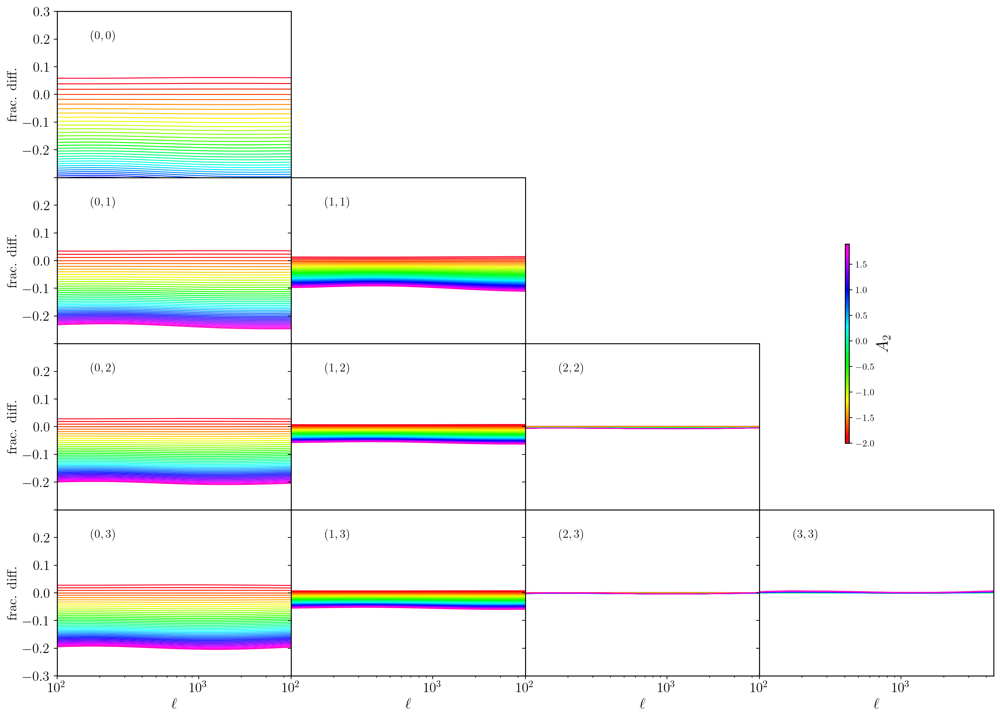

In [18]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=ref,
                          param=param,
                          colorbarlabel="$A_2$",
                          figsize = (18, 13),
                          yaxislabelsize = 15,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          lmin = lmin,
                          lmax = lmax,
                          ylim = [0.7,1.3],
                          wspace=0.4)

## How $\Omega_m$ changes $\xi_\pm(\theta)$

The real-space correlation functions are bin-averaged Legendre sums of the angular spectra, $\xi_+=\sum_\ell G^+_\ell\,(C_\ell^{EE}+C_\ell^{BB})$ and $\xi_-=\sum_\ell G^-_\ell\,(C_\ell^{EE}-C_\ell^{BB})$, where the kernels $G^\pm_\ell(\theta)$ average Legendre functions over each angular bin. At the same angle, $\xi_-$ weights higher multipoles than $\xi_+$, so it is more sensitive to small-scale, nonlinear power. `nw.xi` returns the tuple `(theta, xi_plus, xi_minus)` with `theta` in arcminutes; `pm=1` plots $\xi_+$ and `pm=-1` plots $\xi_-$.

In [19]:
param = np.arange(0.2, 0.4, 0.02)
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(omegam = x))

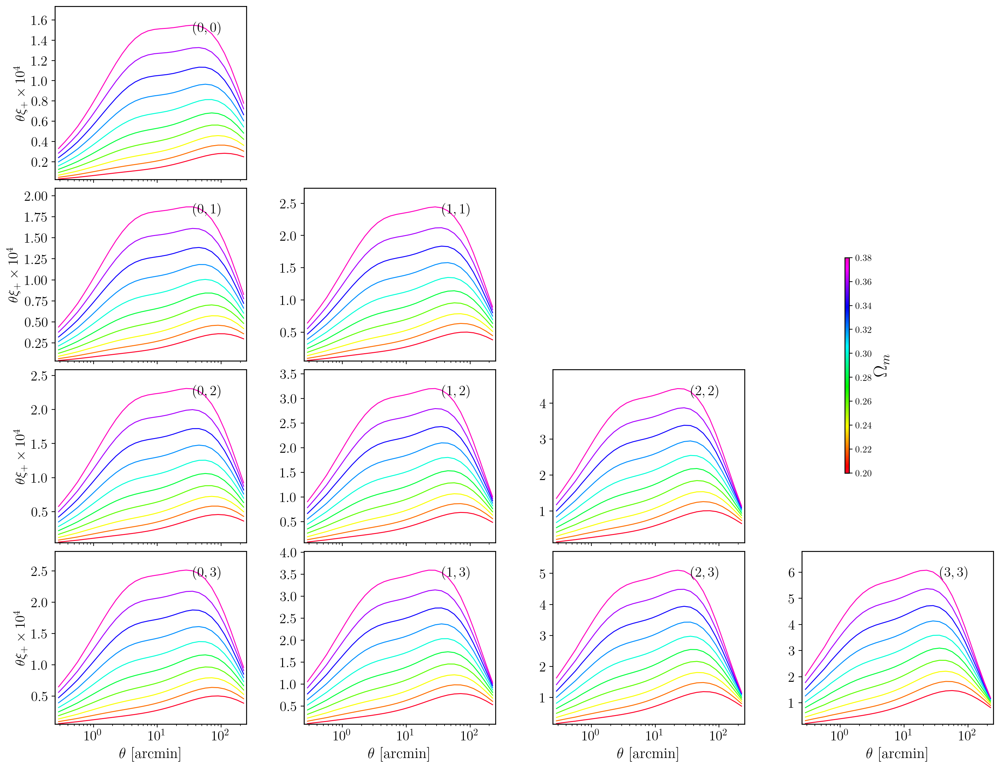

In [20]:
cnu.plot_xi(pm = 1,
            xi = xi_theta,
            param = param,
            colorbarlabel = "$\Omega_m$",
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (18, 14),
            thetashow=[0.25,250],
            wspace=0.3,
            rescale=None)

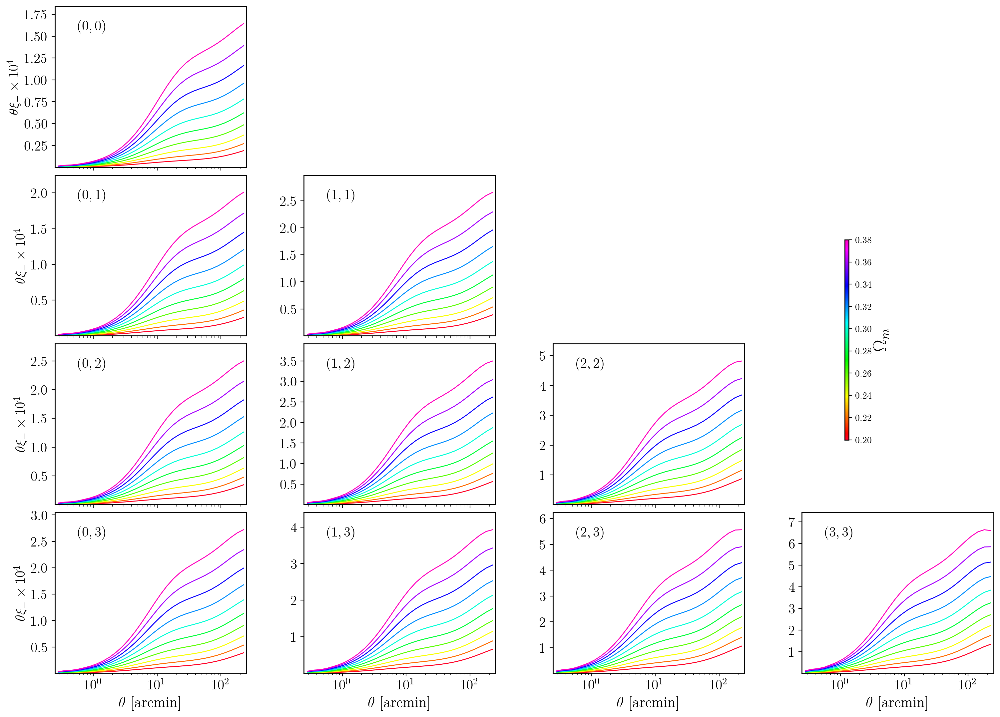

In [21]:
cnu.plot_xi(pm = -1,
            xi = xi_theta,
            param = param,
            colorbarlabel = "$\Omega_m$",
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (18, 13),
            thetashow=[0.25,250],
            wspace=0.3,
            rescale=None)

## Change the angular binning without restarting the kernel

CosmoLike keeps expensive intermediate results in C *static variables*, which persist inside the compiled library between calls. The Legendre kernels $G^\pm_\ell(\theta)$ depend on the angular bins, so a stale copy would silently describe the old binning. Each cache therefore carries a key: `nw.xi(ntheta=...)` calls `ci.init_binning`, which issues a new key whenever the number of bins or the angular range changes, and the kernels are rebuilt. The curves below use 9, 12, 17 and 44 bins between 0.25′ and 250′. Each binning has its own bin centers, so the curves are overlaid as absolute values, one marker style per binning.

In [22]:
nthetas=[9, 12, 17, 44]
result = []
for x in nthetas:
    result.append(nw.xi(ntheta=x))

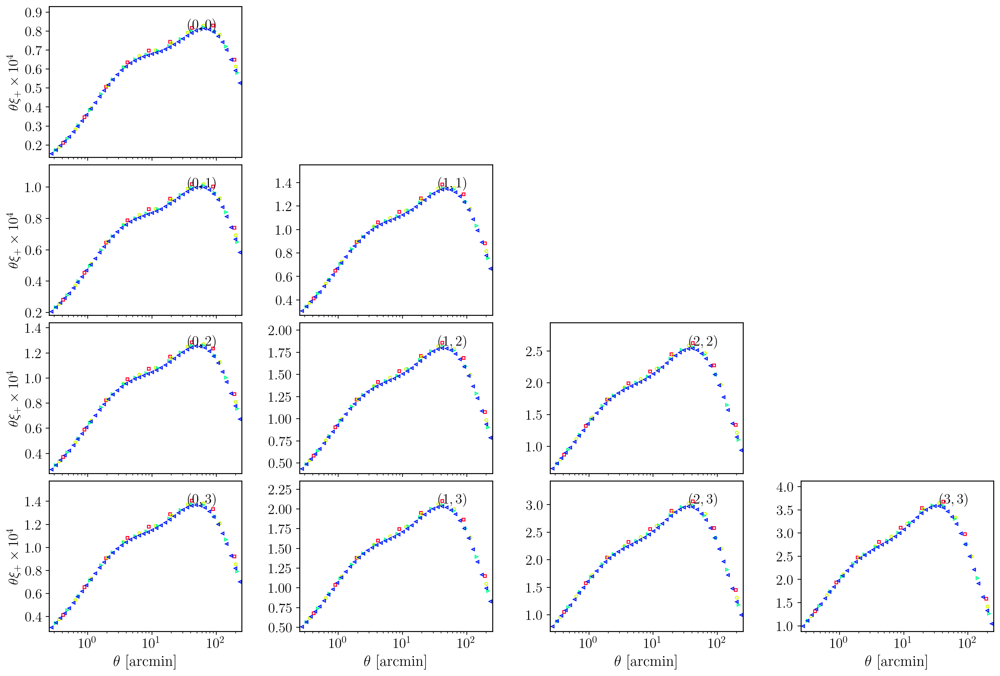

In [23]:
cnu.plot_xi(pm = 1,
            xi = result,
            marker=['s', 'o', ">", "<"],
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (18, 12),
            thetashow=[0.25,250],
            wspace=0.3,
            rescale=None)

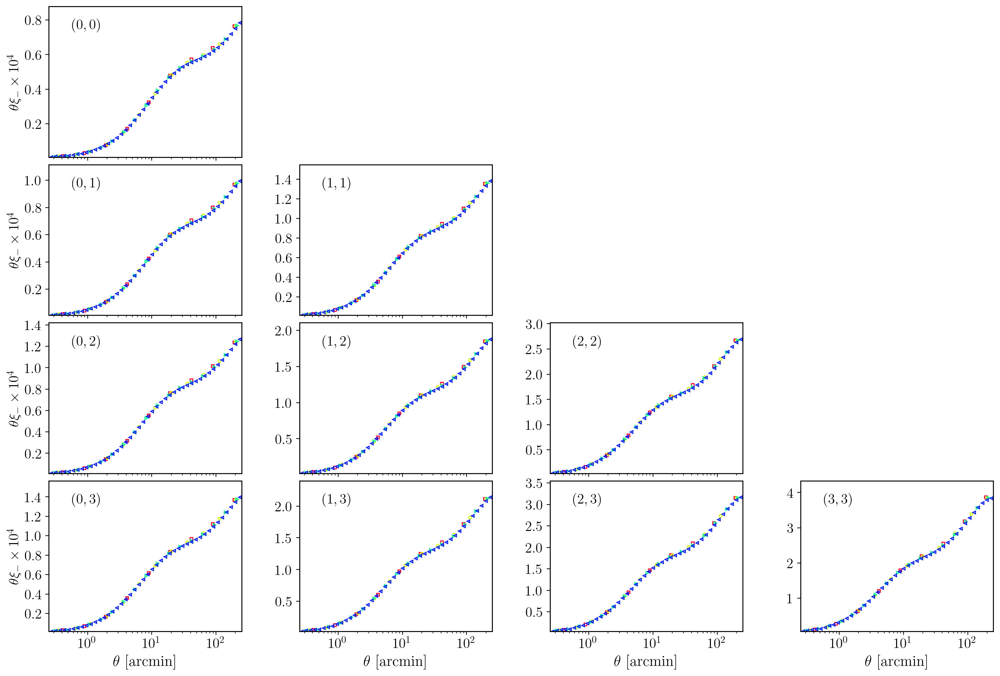

In [24]:
cnu.plot_xi(pm = -1,
            xi = result,
            marker=['s', 'o', ">", "<"],
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (18, 12),
            thetashow=[0.25,250],
            wspace=0.3,
            rescale=None)

## Baryonic feedback in $C_\ell^{EE}$ and $\xi_\pm(\theta)$

Gas cooling, star formation and feedback from supernovae and active galactic nuclei redistribute matter inside halos. Depending on the simulation, they suppress the matter power spectrum by up to a few tens of percent at wavenumbers of a few $h\,\mathrm{Mpc}^{-1}$. `baryon_sims=name` multiplies the nonlinear power spectrum by the ratio $P_{\rm hydro}(k,z)/P_{\rm DMO}(k,z)$ between a hydrodynamical simulation and its dark-matter-only counterpart, read from the HDF5 file `allsims`; `baryon_sims=None` removes it. The nine scenarios come from TNG100, Horizon-AGN, MassiveBlack-II, Illustris, EAGLE, three OWLS AGN variants and BAHAMAS.

Each reference is the same cosmology without feedback, so the panels show the fractional change caused by each scenario. Colors identify the scenarios consistently in all three figures, in the order of `param` that the $\xi_\pm$ legends list. Line styles are not a key: they cycle from panel to panel.

In [25]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = ("TNG100-1", "HzAGN-1", "mb2-1", "illustris-1", "eagle-1", "owls_AGN-1", "owls_AGN-2", "owls_AGN-3", "BAHAMAS-2")
C_ss = []
for x in param:
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, baryon_sims=x,allsims=allsims)
    C_ss.append(Cl)
    
# Reference: the same cosmology without baryonic feedback.
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell)

# 40 angular bins for the curves and the reference alike: a ratio needs
# one theta grid.
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(baryon_sims=x,allsims=allsims, ntheta=40, AccuracyBoost=1.0))

xi_theta_ref = nw.xi(ntheta=40, AccuracyBoost=1.0)

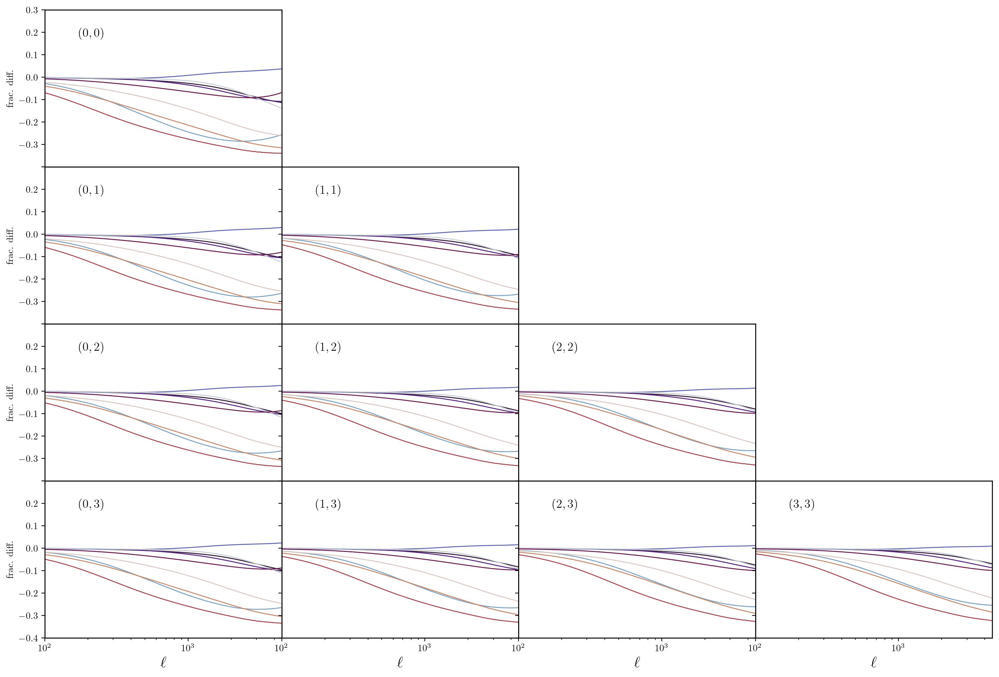

In [26]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          lmin=lmin,
                          lmax=lmax,
                          cmap="twilight_shifted",
                          yaxislabelsize = 10,
                          xaxisticklabelsize=10,
                          yaxisticklabelsize=10,
                          ylim=(0.6,1.3),
                          figsize = (18, 12),
                          wspace=0.4)

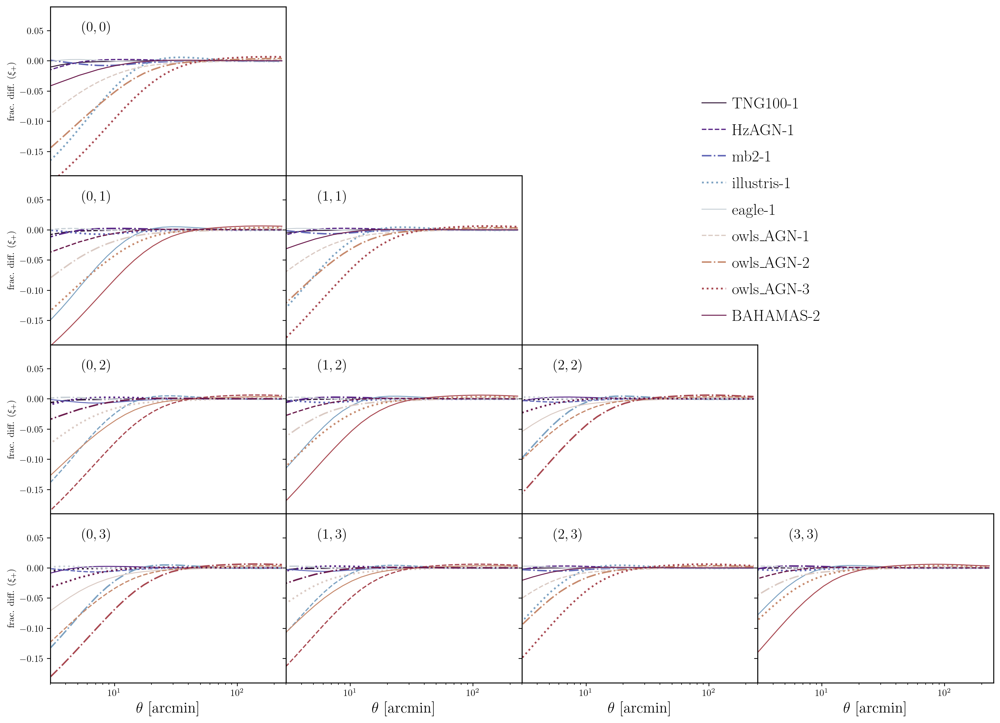

In [27]:
# rcParams changes persist for every later figure of this kernel.
matplotlib.rcParams['legend.fontsize'] = 17
cnu.plot_xi(pm = 1,
            param=None,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            cmap="twilight_shifted",
            ylim=(0.81,1.09),
            linewidth=[1.0, 1.3, 1.6, 1.9],
            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
            legend = param,
            legendloc=(0.7,0.55),
            bintextpos = [[0.2, 0.875],[0.2,0.875]],
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 13),
            wspace=0.4)

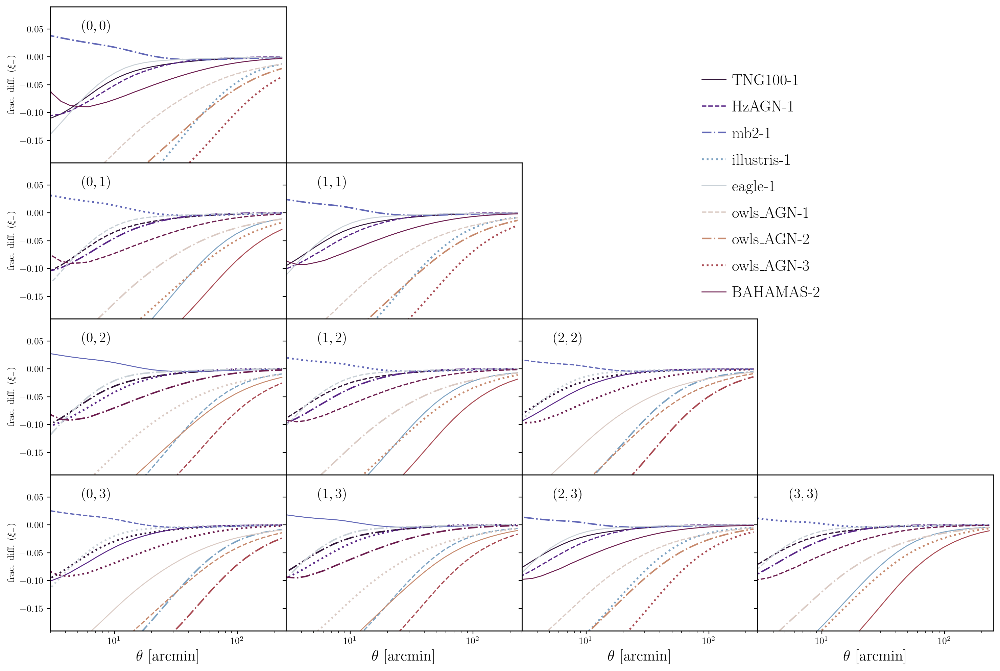

In [28]:
cnu.plot_xi(pm = -1,
            param=None,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            cmap="twilight_shifted",
            ylim=(0.81,1.09),
            linewidth=[1.0, 1.3, 1.6, 1.9],
            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
            legend = param,
            legendloc=(0.7,0.55),
            bintextpos = [[0.2, 0.875],[0.2,0.875]],
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 12),
            wspace=0.4)

## How the accuracy settings change $C_\ell^{EE}$ and $\xi_\pm(\theta)$

Every wrapper accepts four accuracy arguments:

| Argument | What it refines |
| --- | --- |
| `AccuracyBoost` | Both codes at once: CAMB receives $1+(\mathrm{AccuracyBoost}-1)/3$, and the CosmoLike boost is multiplied by `AccuracyBoost`. |
| `CAMBAccuracyBoost` | CAMB only: its internal accuracy, its maximum wavenumber and wavenumber sampling, and the redshift sampling of the distance table. |
| `CLAccuracyBoost` | CosmoLike only: its interpolation tables, the redshift and wavenumber grids of the power-spectrum tables, and the highest multipole of the $C_\ell$ table. |
| `CLIntegrationAccuracy` | CosmoLike's quadrature rules, the level of numerical integration. |

The wrappers add $|3(\mathrm{CLAccuracyBoost}-1)|$ to the integration level, so raising the CosmoLike boost also refines the integrals. The first figures change only the CosmoLike settings, `CLAccuracyBoost = 1 + x` and `CLIntegrationAccuracy = int(x)`; the later ones change only CAMB, `CAMBAccuracyBoost = 1 + x/3`. The colorbars, labeled "Accuracy Boost", show $x$. Each reference uses boost 1 and integration level 0, so a curve shows how far the default settings are from a refined calculation of that quantity. The $\chi^2$ sections below express such changes as $\Delta\chi^2$, the measure the project tests use.

In [29]:
lmin = 100.
lmax = 6500.
ell = np.arange(lmin, lmax, 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
# The colorbar shows x: CLAccuracyBoost = 1 + x and CLIntegrationAccuracy
# = int(x), to which the wrapper adds |3 (CLAccuracyBoost - 1)|.
param = np.arange(1.0, 10.0, 0.5)
C_ss = []
for x in param:
    # Change only Cosmolike Settings
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x))
    C_ss.append(Cl)
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)

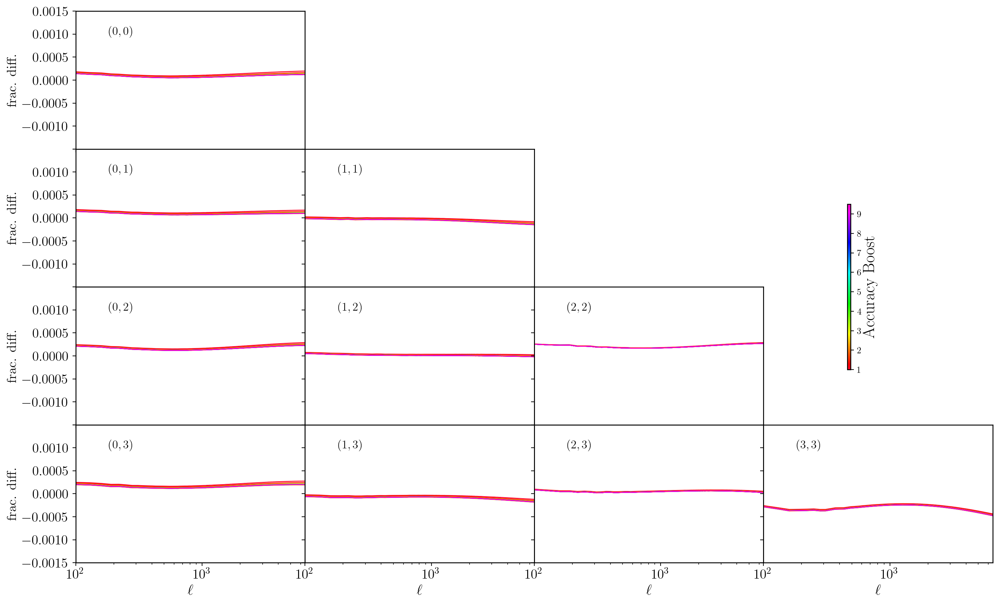

In [30]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          param=param,
                          lmin=lmin,
                          lmax=lmax,
                          ylim=(0.9985,1.0015),
                          colorbarlabel="Accuracy Boost",
                          yaxislabelsize = 15,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          figsize = (18, 11),
                          wspace=0.4)

In [31]:
# x = 0 repeats the reference settings: its curve lies on zero, a check
# of the comparison itself.
param = np.arange(0,10.0,1.0)
xi_theta_ref = nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x)))

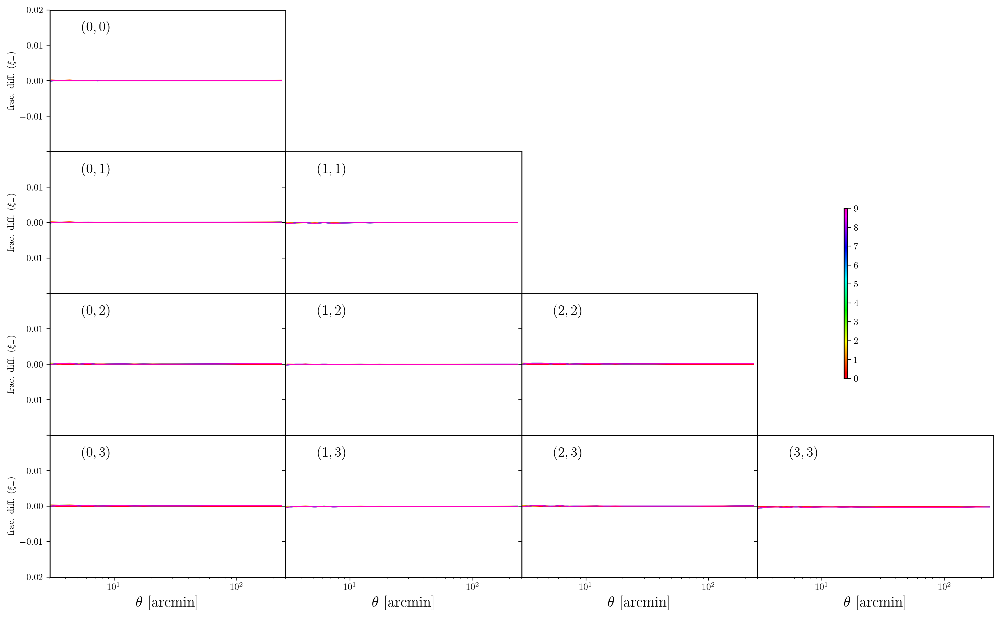

In [32]:
# pm <= 0 draws xi_minus; the next cell draws xi_plus.
cnu.plot_xi(pm=0,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            param=param,
            ylim=(0.98,1.02),
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 11),
            wspace=0.4)

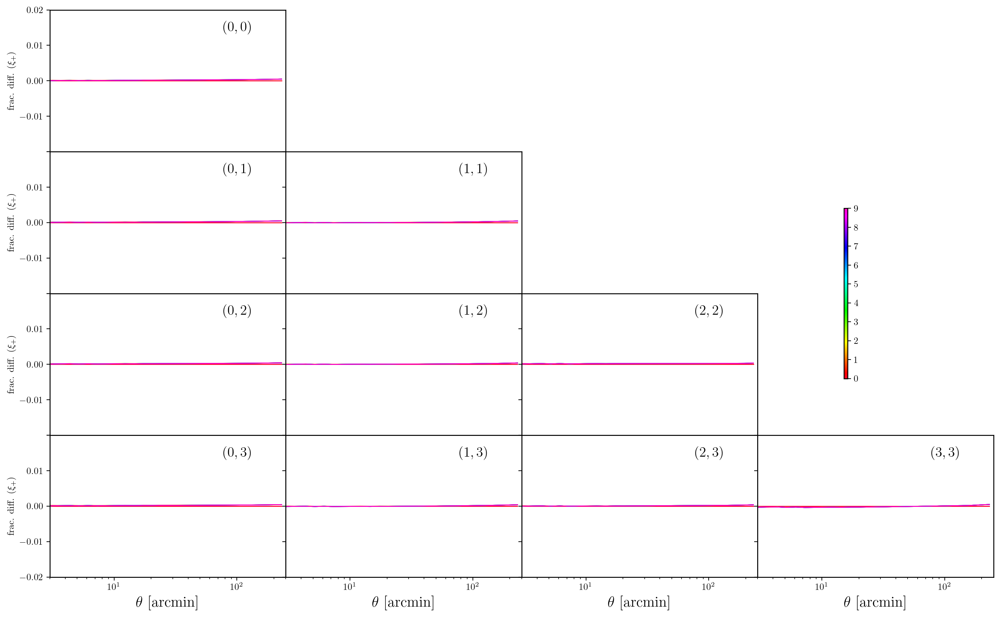

In [33]:
cnu.plot_xi(pm=1,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            param=param,
            ylim=(0.98,1.02),
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 11),
            wspace=0.4)

In [34]:
lmin = 100.
lmax = 6500.
ell = np.arange(lmin, lmax, 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
# CAMBAccuracyBoost = 1 + x/3 also raises CAMB's maximum wavenumber and
# its k sampling (help(cnu.get_camb_cosmology)); the colorbar shows x.
param = np.arange(1.,6.0,1.0)
C_ss = []
for x in param:
    # Change only CAMB Settings
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0)
    C_ss.append(Cl)
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)

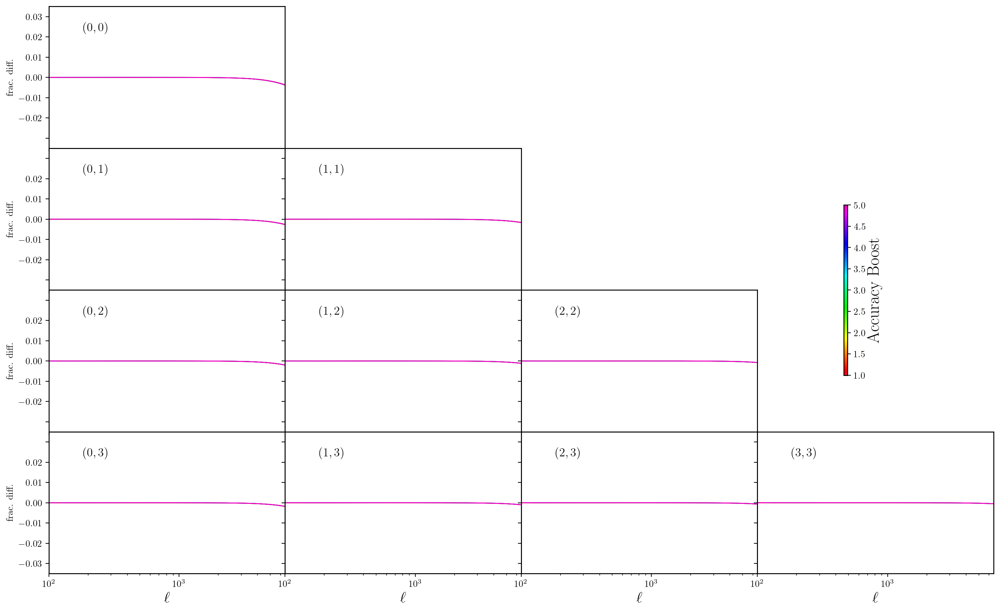

In [35]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          param=param,
                          lmin=lmin,
                          lmax=lmax,
                          ylim=(0.965,1.035),
                          colorbarlabel="Accuracy Boost",
                          yaxislabelsize = 10,
                          xaxisticklabelsize=10,
                          yaxisticklabelsize=10,
                          figsize = (18, 11),
                          wspace=0.4)

In [36]:
param = np.arange(1.,6.0,1.0)
xi_theta_ref = nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0))

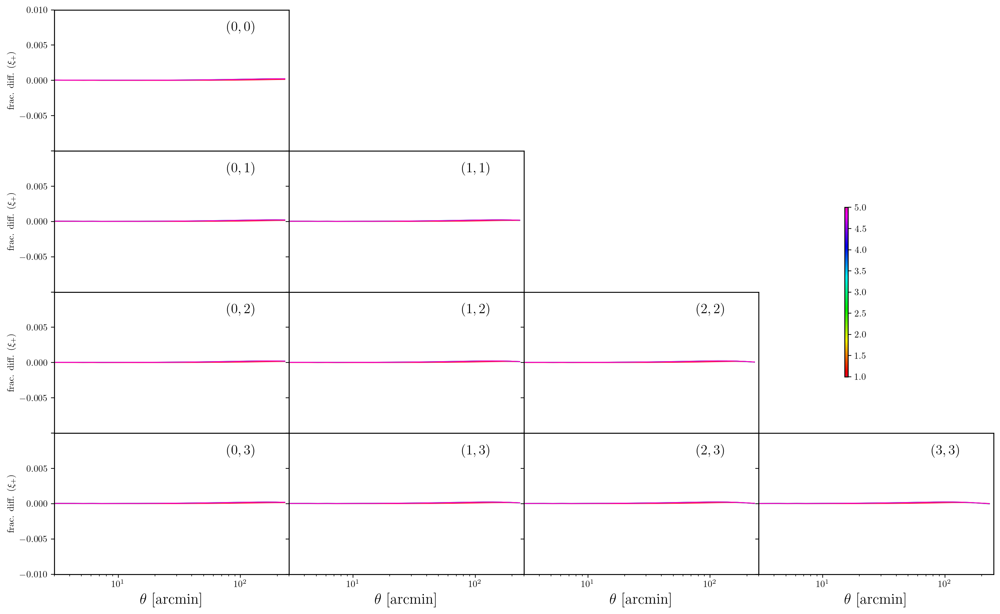

In [37]:
cnu.plot_xi(pm = 1,
            xi = xi_theta,
            xi_ref = xi_theta_ref,
            param=param,
            ylim=(0.99, 1.01),
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 11),
            wspace=0.4)

## The cosmic-shear $\chi^2$ of DES Y3 × Planck PR4

`nw.init_cosmolike(CLprobe="xi", with_data=True)` repeats the initialization, selects the cosmic-shear probe and loads the measured data vector, the covariance and the mask named in the dataset file. The *mask* holds one 0/1 flag per data-vector entry and applies the analysis scale cuts. Together with the probe selection it keeps 400 entries, 200 of $\xi_+$ and 200 of $\xi_-$. `nw.get_chi2` then computes

$$\chi^2=(\mathbf d-\mathbf t)^{\mathsf T}\,\mathbf C^{-1}\,(\mathbf d-\mathbf t),$$

where $\mathbf d$ holds the measurements, $\mathbf t$ the prediction and $\mathbf C$ the supplied covariance, all restricted to the retained entries. `nw.get_chi2(omegam = 0.3)` evaluates the fiducial point, which matches the `override` block of [EXAMPLE_EVALUATE1.yaml](EXAMPLE_EVALUATE1.yaml). That YAML's CAMB block (`kmax: 10`, `k_per_logint: 12`) differs from the notebook's CAMB call (`kmax = 7.5`, `k_per_logint = 10`), so the notebook and the Cobaya run need not agree in every digit. The scan shows how quickly $\chi^2$ changes with $\Omega_m$ between 0.295 and 0.304.

In [38]:
# Re-init with the chi2 machinery: probes, covariance, mask, and
# data vector (nw.init_cosmolike holds the full sequence)
# CLprobe="xi" activates the cosmic-shear blocks only: xi_plus, xi_minus.
ini = nw.init_cosmolike(CLprobe="xi", with_data=True)
allsims = nw.allsims

In [39]:
nw.get_chi2(omegam = 0.3)

748.8886202033655

In [40]:
param = np.arange(0.295, 0.305, 0.001)      
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(omegam = x))

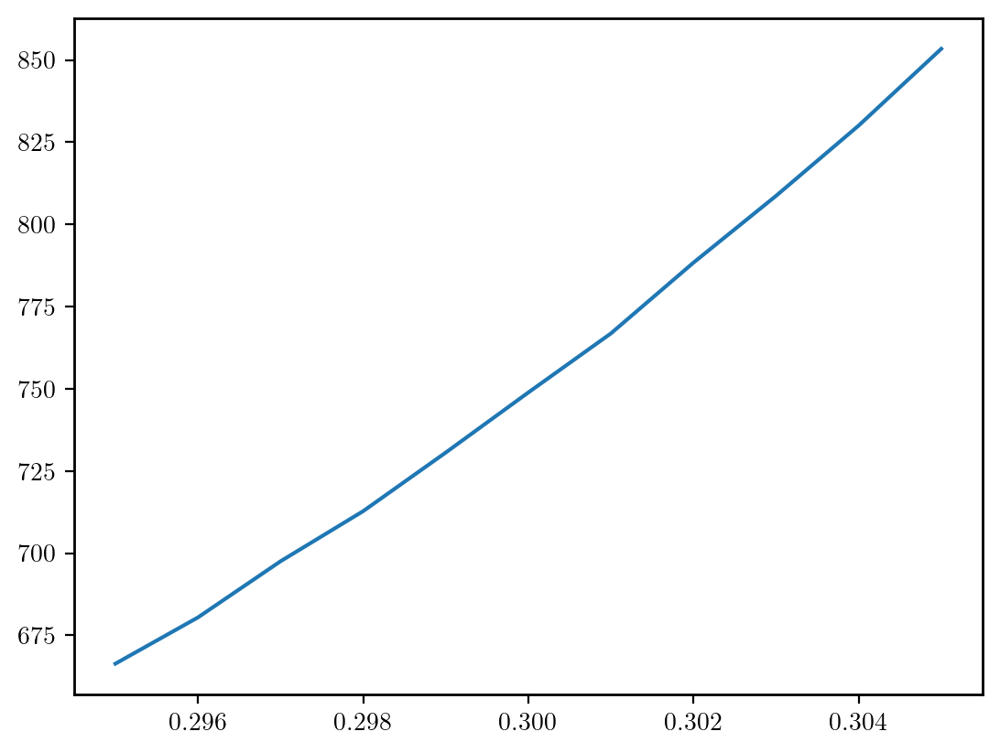

In [41]:
plt.plot(param, chi2)

## $\chi^2$ as a function of the CAMB and CosmoLike accuracy

Both sweeps raise CAMB and CosmoLike together through one variable $x$. The first sets `CAMBAccuracyBoost = 1 + x/3` and `CLAccuracyBoost = 1 + x` at base integration level 1; the second sets `AccuracyBoost = 1 + x`, which applies the same two boosts at base integration level 0. Each figure plots $\chi^2(x)-\chi^2(x_{\rm max})$, the change relative to the most accurate setting of the sweep.

These $\chi^2$ values use the real measurements, and the fiducial point is not their best fit. There $\chi^2$ responds linearly to small changes in the prediction, so a shift measures the slope of $\chi^2$ as much as the numerical error. The project tests therefore measure accuracy against a synthetic data vector computed at the fiducial point; see the [data-vector test guide](tests/data_vector/README.md#synthetic_vectors). Compare the shifts with the 0.2 band in $\Delta\chi^2$ that the reference tests allow.

In [42]:
# One variable x raises CAMB (1 + x/3) and CosmoLike (1 + x) together, at
# integration level 1.
param = np.arange(0., 6., 0.5)      
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(AccuracyBoost = 1, CAMBAccuracyBoost = 1.+ x/3.0, CLAccuracyBoost = 1 + x, CLIntegrationAccuracy = 1))
chi2 = np.array(chi2)

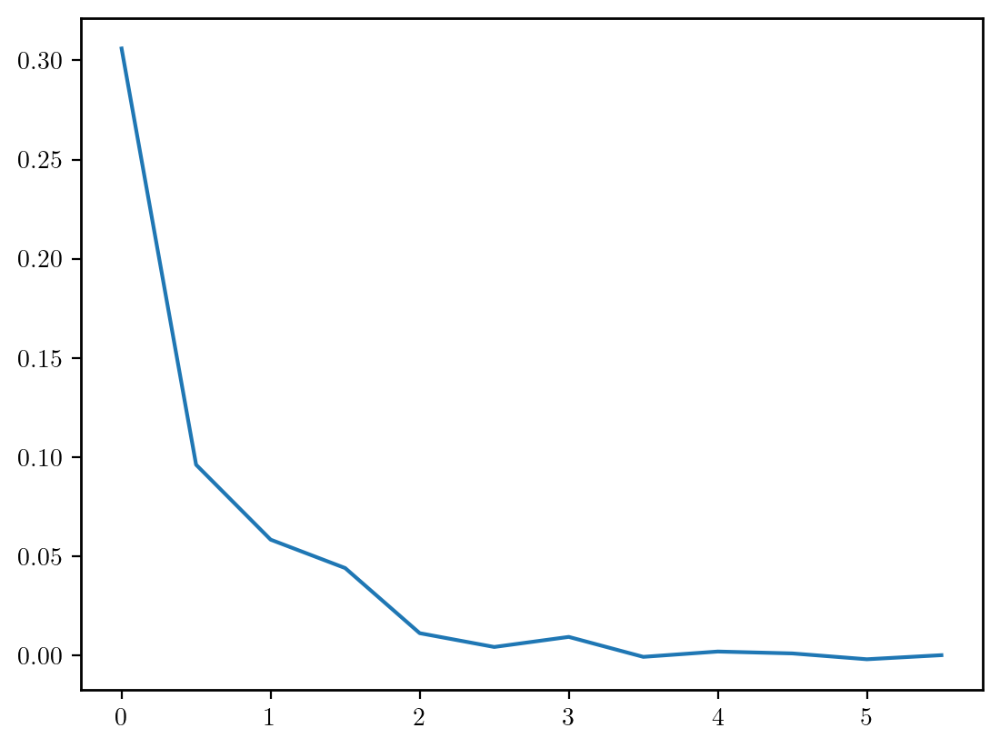

In [43]:
# Change relative to the most accurate setting, the last of the sweep.
plt.plot(param, np.array(chi2 - chi2[-1]))

In [44]:
# AccuracyBoost = 1 + x applies the same CAMB (1 + x/3) and CosmoLike
# (1 + x) boosts as the previous sweep; only the base integration level
# differs (0 here, 1 there).
param = np.arange(0, 6, 0.5)      
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(AccuracyBoost = 1 + x))
chi2 = np.array(chi2)

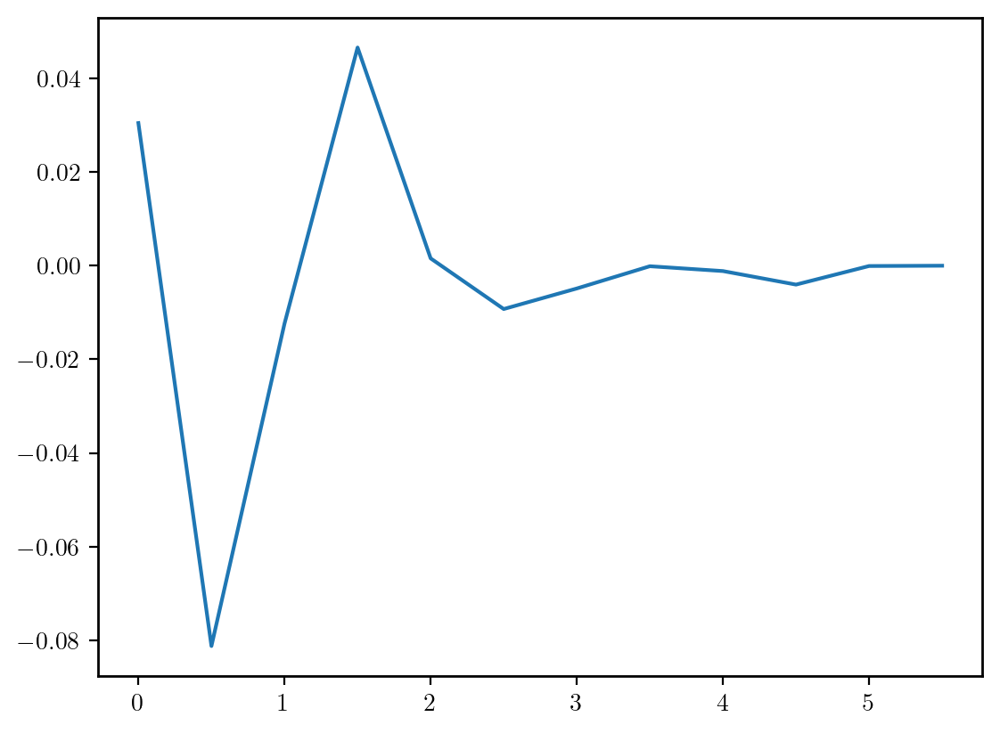

In [45]:
plt.plot(param, np.array(chi2 - chi2[-1]))

## Halofit versus EuclidEmulator2

`non_linear_emul` selects the nonlinear matter power spectrum. The value 2, the default here, uses CAMB's Halofit fitting formula in its Takahashi version. The value 1 multiplies the linear spectrum by the nonlinear boost of EuclidEmulator2, an emulator trained on N-body simulations, below $z=10$, and keeps Halofit above. The first cell prints the cosmic-shear $\chi^2$ for each choice.

The $C_\ell^{EE}$ figure shows $C^{\rm Halofit}/C^{\rm EE2}-1$. The $\xi_+$ figure divides the other way, $\xi_+^{\rm EE2}/\xi_+^{\rm Halofit}-1$, and its EuclidEmulator2 curve uses `CAMBAccuracyBoost` $=4/3$, so that comparison also contains a CAMB accuracy change.

In [46]:
# non_linear_emul = 1 uses EuclidEmulator2, 2 uses CAMB's Halofit.
print(rf"$\chi^2$={nw.get_chi2(non_linear_emul=1):3.3f}")
print(rf"$\chi^2$={nw.get_chi2(non_linear_emul=2):3.3f}")

/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/euclidemu2/ee2_bindata.dat
$\chi^2$=723.202


$\chi^2$=748.889


In [47]:
lmin = 100.
lmax = 6500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = [1]
C_ss = []
for x in param:
    # Halofit (non_linear_emul=2); the reference below uses EuclidEmulator2.
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=2)
    C_ss.append(Cl)
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=1)

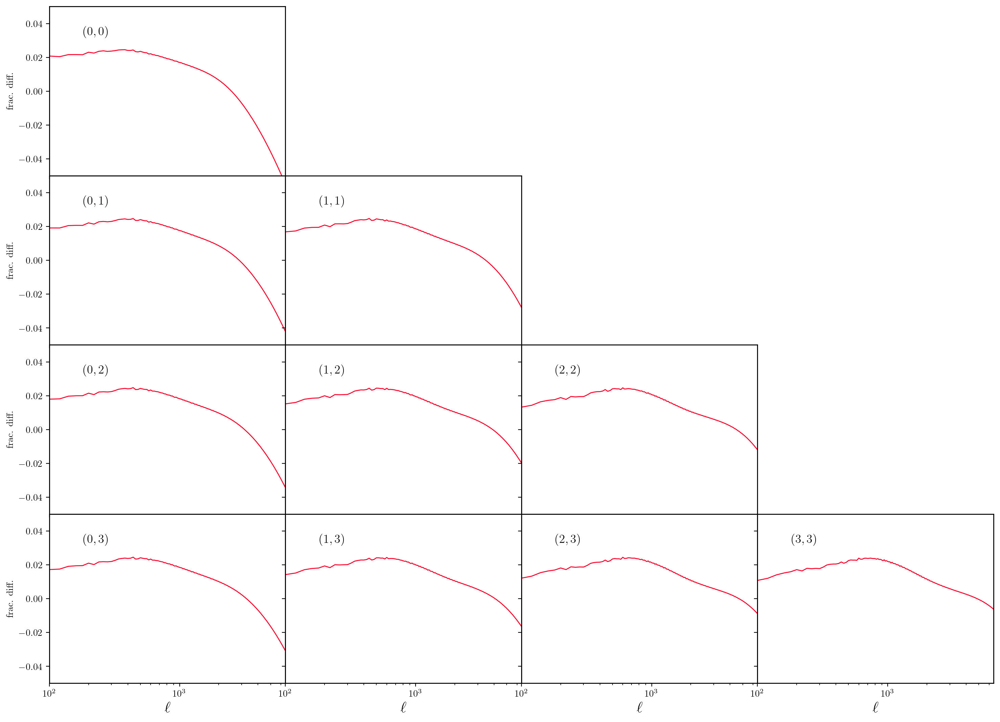

In [48]:
# Halofit / EuclidEmulator2 - 1; one curve, so no colorbar is drawn.
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          param=param,
                          lmin=lmin,
                          lmax=lmax,
                          ylim=(0.95,1.05),
                          colorbarlabel="Accuracy Boost",
                          colorbar=None,
                          yaxislabelsize = 10,
                          xaxisticklabelsize=10,
                          yaxisticklabelsize=10,
                          figsize = (18, 13),
                          wspace=0.3)

In [49]:
# Roles reversed relative to the C_ell figure: the reference is Halofit
# and the curve EuclidEmulator2, computed with CAMBAccuracyBoost = 1 + 1/3,
# so this ratio also contains a CAMB accuracy change.
param = [1]
xi_theta_ref = nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=2)
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=1))

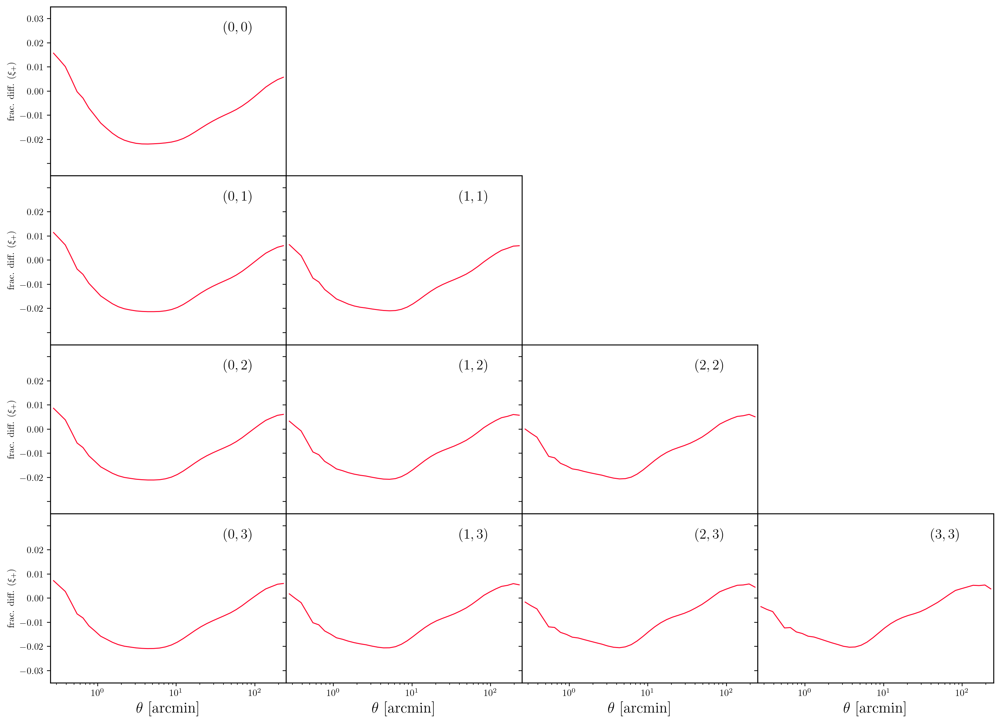

In [50]:
cnu.plot_xi(pm = 1,
            xi = xi_theta,
            xi_ref = xi_theta_ref,
            param=param,
            ylim=(0.965, 1.035),
            colorbar=None,
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 13),
            thetashow=[0.25,250],
            wspace=0.3)

## Which wavenumbers each measurement probes

### Log-response $d\ln C_{\mathrm{ss}}^{\mathrm{EE}} \big/ d\ln k$ (normalized)

A Limber spectrum is an integral of the matter power spectrum along the line of sight, which can be written as an integral over $\ln k$: $C_\ell=\int d\ln k\;dC_\ell/d\ln k$. The log-response $d\ln C_\ell/d\ln k=(dC_\ell/d\ln k)/C_\ell$ is the fraction of the signal contributed per unit $\ln k$. It shows which wavenumbers a multipole measures, the input for choosing scale cuts ([arXiv:2011.06469](https://arxiv.org/abs/2011.06469), Eq. 17). The figure shows the auto-correlations $(i,i)$ of the four source bins (one dash pattern per bin) at $\ell=30$, 300 and 3000 (one color per multipole), each curve divided by its own maximum.

In [51]:
# dlnC_dlss_tomo_limber lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.dlnC_dlss_tomo_limber.

In [52]:
# dlnCEEdlnk has axes [k, ell, i, j] with k in h/Mpc; tmp receives the
# B-mode response.
ell  = [30.,300.,3000.]
kk = 10.0 ** np.arange(-2.2, 1.6, 0.025)
(dlnCEEdlnk, tmp) = nw.dlnC_dlss_tomo_limber(k=kk, ell=ell, CLAccuracyBoost=1.00)

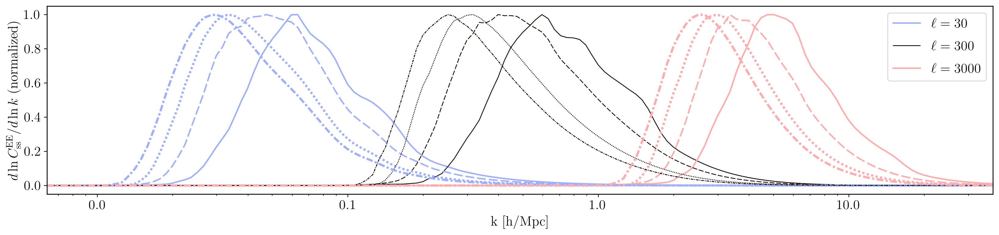

In [53]:
cnu.plot_response_function(k=kk,
                           resp=dlnCEEdlnk,
                           labels=[r"$\ell=30$", r"$\ell=300$", r"$\ell=3000$"],
                           ylabel=r"$d\ln C_{\mathrm{ss}}^{\mathrm{EE}} / d\ln k$ (normalized)",
                           normalize=True,
                           xtickformat="scalar")


### Log-response $d\ln \xi_{\pm} \big/ d\ln k$ (normalized)

The Legendre sums that build $\xi_\pm$ from $C_\ell$, applied to $dC_\ell/d\ln k$, give the log-response of each angular bin. The figures show angular bins 10 and 20 (`idx`, counted from 0), centered near 2.8′ and 28′; the printed array lists all 30 centers in arcminutes. At a given angle, $\xi_-$ responds to larger $k$ than $\xi_+$.

In [54]:
# dlnxi_dlnk_pm_tomo_limber lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.dlnxi_dlnk_pm_tomo_limber.

In [55]:
kk = 10.0**np.arange(-3., 1.02, 0.02)

In [56]:
# theta in arcmin; both responses have axes [k, theta, i, j].
(theta, dlnxip_dlnk, dlnxim_dlnk) = nw.dlnxi_dlnk_pm_tomo_limber(k = kk)

In [57]:
print(theta)

[0.2836022963386458, 0.35703413770390113, 0.44947934883345914, 0.5658609743231364, 0.7123767601180032, 0.8968292060841517, 1.1290410775785265, 1.4213785035230764, 1.7894095178631664, 2.2527331141442906, 2.8360229633864567, 3.570341377039011, 4.494793488334589, 5.658609743231364, 7.12376760118003, 8.968292060841518, 11.290410775785269, 14.21378503523077, 17.894095178631662, 22.527331141442893, 28.36022963386455, 35.70341377039008, 44.94793488334587, 56.58609743231363, 71.2376760118003, 89.68292060841516, 112.90410775785266, 142.13785035230768, 178.9409517863167, 225.27331141442897]


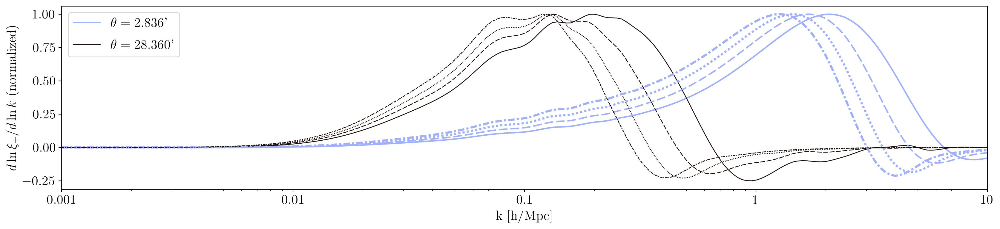

In [58]:
# Angular bins 10 and 20, counted from 0: theta near 2.8 and 28 arcmin.
idx = [10, 20]
cnu.plot_response_function(k=kk,
                           resp=dlnxip_dlnk,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$d\ln \xi_{+} / d\ln k$ (normalized)",
                           normalize=True)


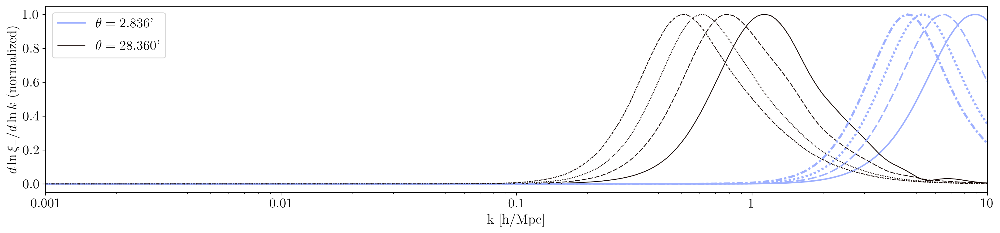

In [59]:
cnu.plot_response_function(k=kk,
                           resp=dlnxim_dlnk,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$d\ln \xi_{-} / d\ln k$ (normalized)",
                           normalize=True)


### Cumulative response $R(k_{\rm max})$ of $C_{\mathrm{ss}}^{\mathrm{EE}}$

$$R_\ell(k_{\rm max})=\frac{\int_{-\infty}^{\ln k_{\rm max}} d\ln k\,\big|d\ln C_{\mathrm{ss}}^{\mathrm{EE}}(\ell)/d\ln k\big|}{\int_{-\infty}^{\infty} d\ln k\,\big|d\ln C_{\mathrm{ss}}^{\mathrm{EE}}(\ell)/d\ln k\big|}$$

$R$ grows from 0 to 1 with $k_{\rm max}$: it is the fraction of a measurement's absolute log-response that comes from wavenumbers below $k_{\rm max}$. Where $R=0.9$, a tenth of the response still comes from larger $k$, where the nonlinear and baryonic modeling is least certain. A scale cut can require $R$ to reach a chosen fraction at a trusted $k_{\rm max}$. These curves are drawn as computed, without normalization.

In [60]:
# rf_C_ss_tomo_limber lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.rf_C_ss_tomo_limber.

In [61]:
# rfCEE has axes [k_max, ell, i, j]; tmp receives the B-mode result.
ell  = [30.,300.,3000.]
kk = 10.0 ** np.arange(-2.2, 1.6, 0.05)
(rfCEE, tmp) = nw.rf_C_ss_tomo_limber(k=kk, ell=ell, CLAccuracyBoost=1.00, CLIntegrationAccuracy=0)

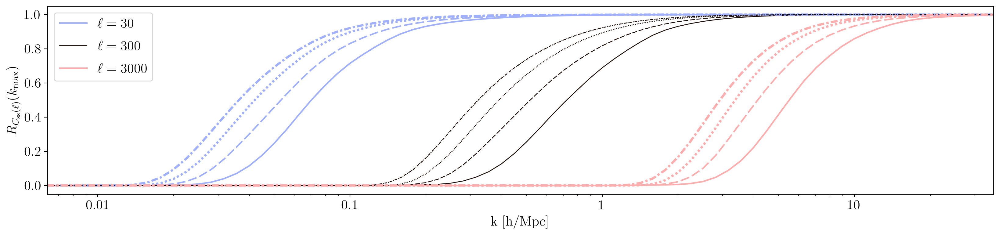

In [62]:
cnu.plot_response_function(k=kk,
                           resp=rfCEE,
                           labels=[r"$\ell=30$", r"$\ell=300$", r"$\ell=3000$"],
                           ylabel=r"$R_{C_{\mathrm{ss}}(\ell)}(k_{\mathrm{max}})$",
                           normalize=False)


### Cumulative response $R(k_{\rm max})$ of $\xi_\pm$

$$R_\theta(k_{\rm max})=\frac{\int_{-\infty}^{\ln k_{\rm max}} d\ln k\,\big|d\ln \xi_\pm(\theta)/d\ln k\big|}{\int_{-\infty}^{\infty} d\ln k\,\big|d\ln \xi_\pm(\theta)/d\ln k\big|}$$

The same fraction for angular bins 10 and 20 of $\xi_+$ and $\xi_-$.

In [63]:
# rf_xi_tomo_limber lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.rf_xi_tomo_limber.

In [64]:
kk = 10.0 ** np.arange(-2, 1.2, 0.02)

In [65]:
# theta in arcmin; rf_xip and rf_xim have axes [k_max, theta, i, j].
(theta, rf_xip, rf_xim) = nw.rf_xi_tomo_limber(k = kk)

In [66]:
print(theta)

[0.2836022963386458, 0.35703413770390113, 0.44947934883345914, 0.5658609743231364, 0.7123767601180032, 0.8968292060841517, 1.1290410775785265, 1.4213785035230764, 1.7894095178631664, 2.2527331141442906, 2.8360229633864567, 3.570341377039011, 4.494793488334589, 5.658609743231364, 7.12376760118003, 8.968292060841518, 11.290410775785269, 14.21378503523077, 17.894095178631662, 22.527331141442893, 28.36022963386455, 35.70341377039008, 44.94793488334587, 56.58609743231363, 71.2376760118003, 89.68292060841516, 112.90410775785266, 142.13785035230768, 178.9409517863167, 225.27331141442897]


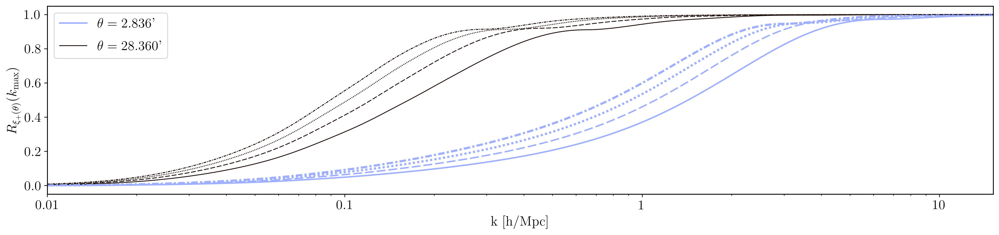

In [67]:
# Angular bins 10 and 20, counted from 0: theta near 2.8 and 28 arcmin.
idx = [10, 20]
cnu.plot_response_function(k=kk,
                           resp=rf_xip,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$R_{\xi_+(\theta)}(k_{\mathrm{max}})$",
                           normalize=False)


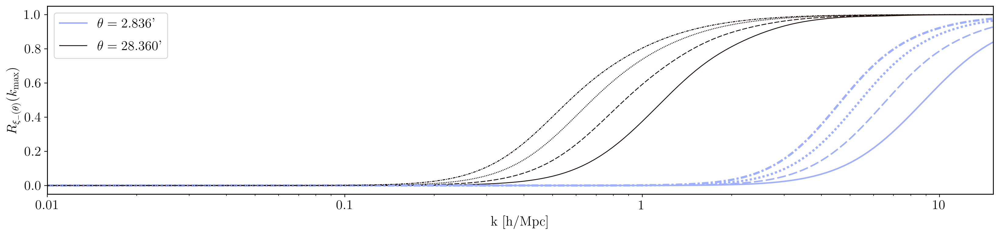

In [68]:
cnu.plot_response_function(k=kk,
                           resp=rf_xim,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$R_{\xi_-(\theta)}(k_{\mathrm{max}})$",
                           normalize=False)


## CMB lensing × shear: $C_\ell^{\kappa s}$ and $w_{\kappa s}(\theta)$

CMB photons are deflected by all the matter between the last-scattering surface ($z\approx1090$) and the observer, so the reconstructed lensing convergence $\kappa$ of Planck PR4 correlates with the cosmic shear of each DES source bin. $\kappa$ has a single source plane, so the arrays carry one tomographic index, the source bin $i$, and only the shear nuisance parameters enter.

- $C_\ell^{\kappa s}$, axes `[ell, i]`, is the Limber cross-spectrum, drawn as $\ell(\ell+1)C_\ell/2\pi$.
- $w_{\kappa s}(\theta)$, axes `[theta, i]` with $\theta$ in arcminutes, is the real-space correlation of $\kappa$ with the tangential shear. It includes the filtering of the lensing map set in the dataset file: a Gaussian beam of 7′ full width at half maximum, the HEALPix pixel window and the multipole range $8\le\ell\le2048$. $C_\ell^{\kappa s}$ omits that filter.

$w_{\kappa s}(\theta)$ is the CMB lensing × shear block of the 6x2pt data vector (120 entries). The covariance generated by this project's covariance notebook does not include it.

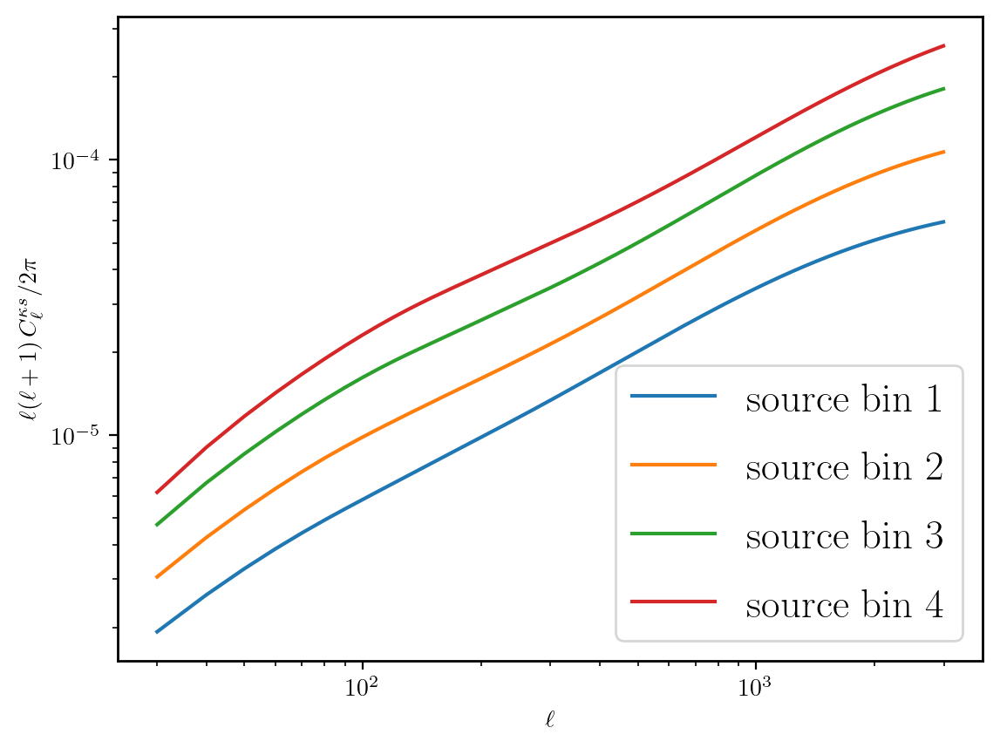

In [69]:
# C_ks_tomo_limber, w_ks, and their scale-cut diagnostics live in this
# project's interface/ (cosmolike_desy1xplanck_notebook_wrappers,
# imported above as nw); the CMB beam/pixel-window filter entering the
# w_ks projection was initialized by nw.init_cosmolike from the
# .dataset keys.
lmin = 30.
lmax = 3000.
ell = np.arange(lmin, lmax, 10.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
Cks = np.array(nw.C_ks_tomo_limber(ell=ell))
for b in range(Cks.shape[1]):
    plt.loglog(ell, ell*(ell + 1)*Cks[:, b]/(2*np.pi),
               label=rf"source bin {b + 1}")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)\, C_\ell^{\kappa s}/2\pi$")
plt.legend()

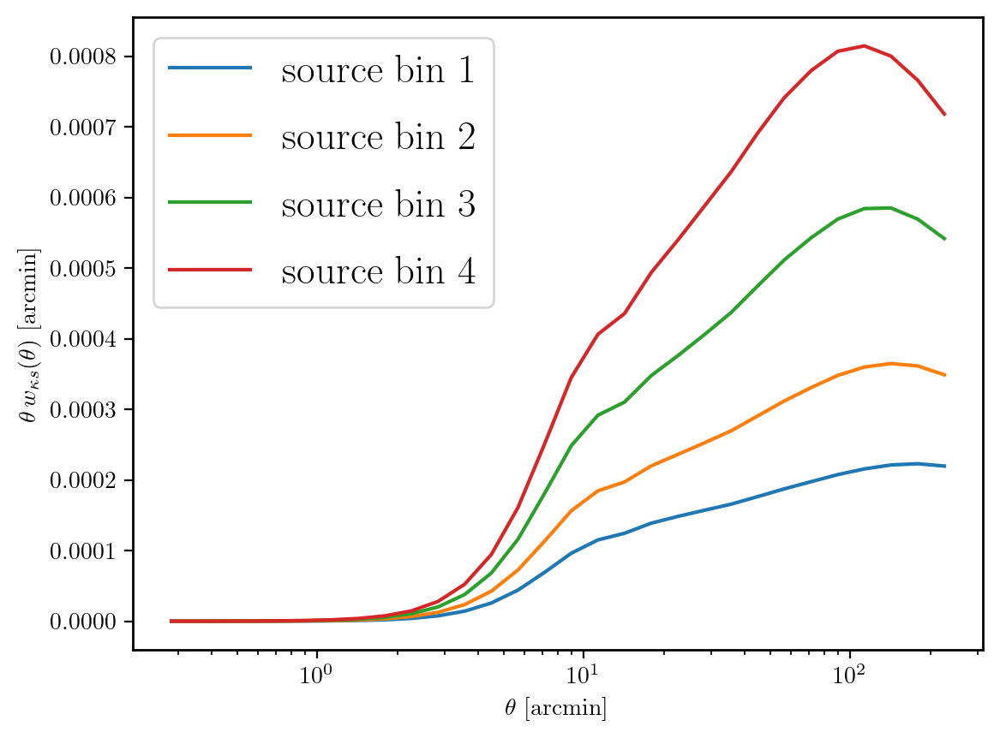

In [70]:
# w_ks includes the lensing-map filter (beam, pixel window, 8 <= ell <= 2048);
# axes [theta, source bin], theta in arcmin.
(theta, wks) = nw.w_ks()
wks = np.array(wks)
for b in range(wks.shape[1]):
    plt.semilogx(theta, theta*wks[:, b], label=rf"source bin {b + 1}")
plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$\theta\, w_{\kappa s}(\theta)$ [arcmin]")
plt.legend()

### Log-response $d\ln C_{\kappa s} \big/ d\ln k$ (normalized)

The log-response of the CMB lensing × shear spectrum at $\ell=30$, 300 and 3000, one dash pattern per source bin; `dlnCks` has axes `[k, ell, i]`.

In [71]:
# dlnCks has axes [k, ell, i]: one source index, because the CMB lensing
# map has a single source plane.
ell  = [30.,300.,3000.]
kk = 10.0 ** np.arange(-2.2, 1.6, 0.025)
dlnCks = nw.dlnC_ks_dlnk_tomo_limber(k=kk, ell=ell)

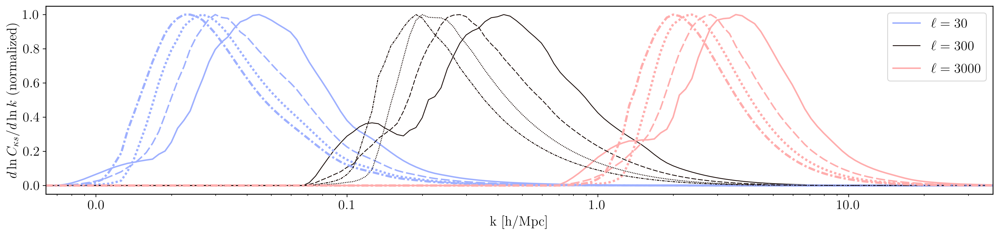

In [72]:
cnu.plot_response_function(k=kk,
                           resp=dlnCks,
                           labels=[r"$\ell=30$", r"$\ell=300$", r"$\ell=3000$"],
                           ylabel=r"$d\ln C_{\kappa s} / d\ln k$ (normalized)",
                           normalize=True,
                           xtickformat="scalar")


### Log-response $d\ln w_{\kappa s} \big/ d\ln k$ (normalized)

The log-response of $w_{\kappa s}$ in angular bins 10 and 20, one dash pattern per source bin. Like $w_{\kappa s}$ itself, it includes the filter of the lensing map.

In [73]:
# dlnwks has axes [k, theta, i]; theta in arcmin.
kk = 10.0**np.arange(-3., 1.02, 0.02)
(theta, dlnwks) = nw.dlnw_ks_dlnk_tomo(k = kk)
print(theta)

[0.2836022963386458, 0.35703413770390113, 0.44947934883345914, 0.5658609743231364, 0.7123767601180032, 0.8968292060841517, 1.1290410775785265, 1.4213785035230764, 1.7894095178631664, 2.2527331141442906, 2.8360229633864567, 3.570341377039011, 4.494793488334589, 5.658609743231364, 7.12376760118003, 8.968292060841518, 11.290410775785269, 14.21378503523077, 17.894095178631662, 22.527331141442893, 28.36022963386455, 35.70341377039008, 44.94793488334587, 56.58609743231363, 71.2376760118003, 89.68292060841516, 112.90410775785266, 142.13785035230768, 178.9409517863167, 225.27331141442897]


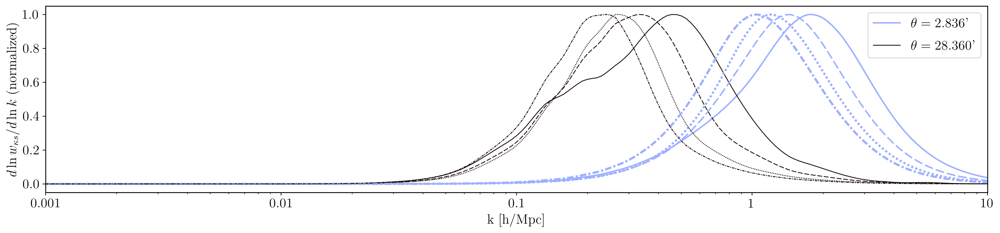

In [74]:
# Angular bins 10 and 20, counted from 0: theta near 2.8 and 28 arcmin.
idx = [10, 20]
cnu.plot_response_function(k=kk,
                           resp=dlnwks,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$d\ln w_{\kappa s} / d\ln k$ (normalized)",
                           normalize=True)


### Cumulative response $R(k_{\rm max})$ of $C_{\kappa s}$

$$R_\ell(k_{\rm max})=\frac{\int_{-\infty}^{\ln k_{\rm max}} d\ln k\,\big|d\ln C_{\kappa s}(\ell)/d\ln k\big|}{\int_{-\infty}^{\infty} d\ln k\,\big|d\ln C_{\kappa s}(\ell)/d\ln k\big|}$$

The fraction of the absolute log-response below $k_{\rm max}$, at $\ell=30$, 300 and 3000.

In [75]:
# rfCks has axes [k_max, ell, i].
ell  = [30.,300.,3000.]
kk = 10.0 ** np.arange(-2.2, 1.6, 0.05)
rfCks = nw.rf_C_ks_tomo_limber(k=kk, ell=ell)

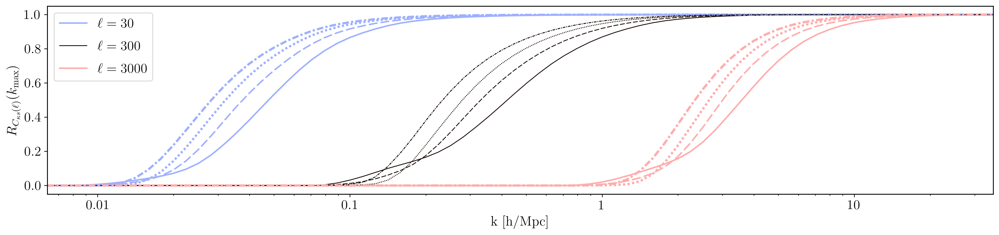

In [76]:
cnu.plot_response_function(k=kk,
                           resp=rfCks,
                           labels=[r"$\ell=30$", r"$\ell=300$", r"$\ell=3000$"],
                           ylabel=r"$R_{C_{\kappa s}(\ell)}(k_{\mathrm{max}})$",
                           normalize=False)


### Cumulative response $R(k_{\rm max})$ of $w_{\kappa s}$

$$R_\theta(k_{\rm max})=\frac{\int_{-\infty}^{\ln k_{\rm max}} d\ln k\,\big|d\ln w_{\kappa s}(\theta)/d\ln k\big|}{\int_{-\infty}^{\infty} d\ln k\,\big|d\ln w_{\kappa s}(\theta)/d\ln k\big|}$$

The same fraction for angular bins 10 and 20.

In [77]:
# rfwks has axes [k_max, theta, i]; theta in arcmin.
kk = 10.0 ** np.arange(-2, 1.2, 0.02)
(theta, rfwks) = nw.rf_w_ks_tomo(k = kk)
print(theta)

[0.2836022963386458, 0.35703413770390113, 0.44947934883345914, 0.5658609743231364, 0.7123767601180032, 0.8968292060841517, 1.1290410775785265, 1.4213785035230764, 1.7894095178631664, 2.2527331141442906, 2.8360229633864567, 3.570341377039011, 4.494793488334589, 5.658609743231364, 7.12376760118003, 8.968292060841518, 11.290410775785269, 14.21378503523077, 17.894095178631662, 22.527331141442893, 28.36022963386455, 35.70341377039008, 44.94793488334587, 56.58609743231363, 71.2376760118003, 89.68292060841516, 112.90410775785266, 142.13785035230768, 178.9409517863167, 225.27331141442897]


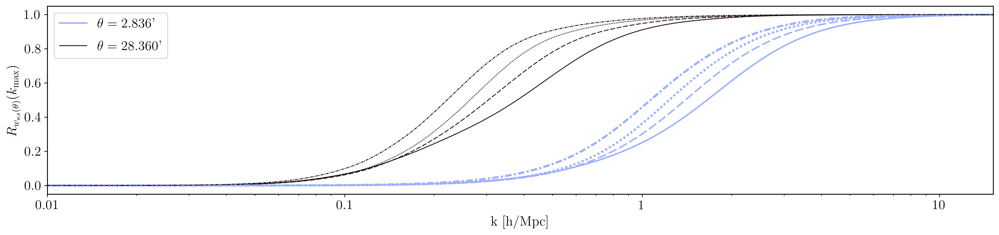

In [78]:
# Angular bins 10 and 20, counted from 0: theta near 2.8 and 28 arcmin.
idx = [10, 20]
cnu.plot_response_function(k=kk,
                           resp=rfwks,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$R_{w_{\kappa s}(\theta)}(k_{\mathrm{max}})$",
                           normalize=False)
